# Sistema y simulación

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from numba import njit, prange
import seaborn as sns

def construir_matriz_ISLM(N, C, sigma, mu_K=0, sigma_K=1):
    """
    Construye la matriz de interacción A siguiendo el ensamble balanceado
    del artículo de Calvo et al. (2026).
    """
    # 1. Generar las capacidades de carga K_i (Log-normal)
    K = np.random.lognormal(mean=mu_K, sigma=sigma_K, size=N)
    
    # 2. Matriz de conectividad B (Bernoulli con probabilidad C)
    B = (np.random.rand(N, N) < C).astype(float)
    np.fill_diagonal(B, 0) # Sin auto-interacciones en la red aleatoria
    
    # 3. Matriz de pesos aleatorios Z con varianza 1/N
    Z = np.random.normal(0, 1.0 / np.sqrt(N), size=(N, N))
    np.fill_diagonal(Z, 0)
    
    # 4. Balancear las filas para obtener G (suma por fila = 0)
    G = np.zeros((N, N))
    for i in range(N):
        indices_activos = np.where(B[i, :] == 1)[0]
        if len(indices_activos) > 0:
            z_activos = Z[i, indices_activos]
            # Restamos la media de los enlaces activos de esa fila
            G[i, indices_activos] = z_activos - np.mean(z_activos)
            
    # 5. Ensamble final: A_ij = sigma * G_ij / K_j  (para i != j)
    # Usamos broadcasting de numpy para dividir eficientemente cada columna j por K[j]
    A = sigma * (G / K[np.newaxis, :])
    
    # Forzamos la diagonal D_ii = -1 / K_i
    np.fill_diagonal(A, -1.0 / K)
    
    return A, K

@njit(fastmath=True, parallel=True)
def getMaxRealPart(N, C_range, n_average, sigma_n_range, sigma_ln_range):
    # Dimensiones de los rangos
    n_connect = C_range.shape[0]
    n_sn = sigma_n_range.shape[0]
    n_sln = sigma_ln_range.shape[0]
    
    # El resultado final es un array 3D: (conectividad, sigma_n, sigma_ln)
    list_eigvals_avg = np.zeros((n_connect, n_sn, n_sln), dtype=np.float64)
    
    # Pre-calculamos N_c para evitar operaciones repetitivas
    N_c_list = (N * N * C_range).astype(np.int64)

    # Bucle 1: Paralelizamos SOLO el nivel más externo
    for i in prange(n_connect):
        N_c = N_c_list[i]
        
        # Bucles internos usan range normal
        for j in range(n_sn):
            sn = sigma_n_range[j]
            
            for k in range(n_sln):
                sln = sigma_ln_range[k]
                sum_max_re = 0.0
                
                # Bucle de Monte Carlo
                for t in range(n_average):
                    
                    # 1. Poblamos la matriz A usando Muestreo por Rechazo
                    A_flat = np.zeros(N * N, dtype=np.float64)
                    is_filled = np.zeros(N * N, dtype=np.bool_) # Control de posiciones
                    
                    if N_c <= (N * N) // 2:
                        # Opción A: Baja densidad. Buscamos casillas vacías y las llenamos
                        added = 0
                        while added < N_c:
                            idx = np.random.randint(0, N * N)
                            if not is_filled[idx]:
                                A_flat[idx] = np.random.normal(0.0, sn)
                                is_filled[idx] = True
                                added += 1
                    else:
                        # Opción B: Alta densidad. Llenamos TODO y luego vaciamos huecos
                        for idx in range(N * N):
                            A_flat[idx] = np.random.normal(0.0, sn)
                            is_filled[idx] = True
                            
                        to_remove = (N * N) - N_c
                        removed = 0
                        while removed < to_remove:
                            idx = np.random.randint(0, N * N)
                            if is_filled[idx]:
                                A_flat[idx] = 0.0
                                is_filled[idx] = False
                                removed += 1
                                
                    A = A_flat.reshape((N, N))

                    # 2. Generamos K y ajustamos diagonal de A
                    K = np.random.lognormal(0.0, sln, N)
                    for diag_idx in range(N):
                        A[diag_idx, diag_idx] = -1.0 / K[diag_idx]

                    # 3. Calculamos el Jacobiano J
                    J = np.zeros((N, N), dtype=np.float64)
                    for r in range(N):
                        row_sum = 0.0
                        for c in range(N):
                            val = A[r, c] * K[c]
                            J[r, c] = val
                            row_sum += val
                        # La diagonal de J es la suma de la fila de A_ij * K_j
                        J[r, r] = row_sum

                    # 4. Calculamos autovalores SIN forzar a complejo (más rápido)
                    vals = np.linalg.eigvals(J)
                    
                    # 5. Buscamos la parte real máxima
                    max_re = -np.inf 
                    for v in vals:
                        if v.real > max_re:
                            max_re = v.real
                    
                    sum_max_re += max_re
                
                # Guardamos el promedio
                list_eigvals_avg[i, j, k] = sum_max_re / n_average
                
    return list_eigvals_avg

@njit(fastmath=True)
def drift(x, tau, K):
    return x/tau * (1 - x/K)

@njit(fastmath=True)
def diffusion(x, tau, sigma, epsilon):
    return x * sigma/tau * epsilon

@njit(fastmath=True)
def time_series(x_0, steps, dt, params):
    tau, K, sigma = params
    x = np.zeros(steps)
    x[0] = x_0[0]
    epsilon = np.random.standard_normal(steps)

    for i in range(1, steps):
        # Primero calculamos el término predictor del algoritmo de Heun
        drift_predictor = drift(x[i-1], tau, K)
        diffusion_predictor = diffusion(x[i-1], tau, sigma, epsilon[i-1])
        x_pred = x[i-1] + dt * drift_predictor + np.sqrt(dt) * diffusion_predictor

        # Y ahora el corrector
        drift_corrector = drift(x_pred, tau, K)
        diffusion_corrector = diffusion(x_pred, tau, sigma, epsilon[i-1])

        # Y finalmente promediamos las dos
        x[i] = x[i-1] + dt * 0.5 * (drift_predictor + drift_corrector) + np.sqrt(dt) * 0.5 * (diffusion_predictor + diffusion_corrector)

    return x

@njit
def samples(x_0, steps, dt, params):
    tau, K, sigma = params
    N = np.shape(x_0)[0]
    x = x_0

    for i in range(1, steps):
        epsilon = np.random.standard_normal(N)
        # Primero calculamos el término predictor del algoritmo de Heun
        drift_predictor = drift(x, tau, K)
        diffusion_predictor = diffusion(x, tau, sigma, epsilon)
        x_pred = x + dt * drift_predictor + np.sqrt(dt) * diffusion_predictor

        # Y ahora el corrector
        drift_corrector = drift(x_pred, tau, K)
        diffusion_corrector = diffusion(x_pred, tau, sigma, epsilon)

        # Y finalmente promediamos las dos
        x += dt * 0.5 * (drift_predictor + drift_corrector) + np.sqrt(dt) * 0.5 * (diffusion_predictor + diffusion_corrector)


    return x

@njit(fastmath=True)
def interacting_time_series(x_0, sigma, tau, dt, A, steps):
    N_species = x_0.shape[0]
    int_time_series = np.zeros((steps, N_species))
    int_time_series[0] = x_0
    for t in range(1, steps):
        for i in range(N_species):
            interaction_term = 0
            for j in range(N_species):
                interaction_term += A[i, j] * int_time_series[t-1, j]

            x_i = int_time_series[t-1, i]
            drift = x_i / tau * (1 + interaction_term)
            diffusion = x_i * sigma * np.random.standard_normal()
            int_time_series[t, i] = x_i + dt * drift + np.sqrt(dt) * diffusion
    
    return int_time_series

@njit(fastmath=True)
def deterministic_interacting_time_series(x_0, tau, dt, A, steps):
    N_species = x_0.shape[0]
    int_time_series = np.zeros((steps, N_species))
    int_time_series[0] = x_0
    for t in range(1, steps):
        for i in range(N_species):
            interaction_term = 0
            for j in range(N_species):
                interaction_term += A[i, j] * int_time_series[t-1, j]

            int_time_series[t, i] = int_time_series[t-1, i] + dt * int_time_series[t-1, i] / tau * (1 + interaction_term)
    
    return int_time_series

@njit(fastmath=True)
def drift(x, tau, K):
    return x/tau * (1 - x/K)

@njit(fastmath=True)
def diffusion(x, tau, sigma, epsilon):
    return x * sigma/tau * epsilon

@njit(fastmath=True)
def third_law(x_0, steps, dt, params):
    tau, K_range, sigma = params
    N = np.shape(x_0)[0]
    x = x_0
    mean_abundance = np.zeros(N)
    avg_steps = int(0.7 * steps)

    for i in range(1, steps):
        epsilon = np.random.standard_normal(N)
        for j in range(N):

            x[j] += dt *drift(x[j], tau, K_range[j]) + np.sqrt(dt) * diffusion(x[j], tau, sigma, epsilon[i])
            if i > 0.3 * steps:
                mean_abundance[j] += x[j]

    mean_abundance = mean_abundance/avg_steps
    return mean_abundance

# Tercera ley
@njit(fastmath=True)
def third_law_interaccion(x_0, steps, dt, params, A):
    tau, K_range, sigma = params
    N = np.shape(x_0)[0]
    x = x_0.copy()

    for i in range(1, steps):
        epsilon = np.random.standard_normal(N)
        x_previo = x.copy()
        for j in range(N):

            termino_drift = drift_interaccion(x_previo[j], tau, A[j, :], x_previo)
            termino_diff = diffusion_interaccion(x_previo[j], sigma, epsilon[j])

            # Actualización del Euler-Maruyama
            x[j] = x_previo[j] + dt * termino_drift + np.sqrt(dt) * termino_diff

    return x


@njit(fastmath=True)
def interacting_time_series_noise(x_0, sigma, tau, dt, A, steps, rho, tau_noise, W):
    N_species = x_0.shape[0]
    int_time_series = np.zeros((steps, N_species))
    int_time_series[0] = x_0
    eta = np.zeros(N_species)
     
    for i in range(1, steps):
        
        ruido_loc = np.random.standard_normal(N_species)
        #ruido_loc=0.0
        ruido_global = W @ ruido_loc
        ruido = rho * ruido_global + (1-rho) * ruido_loc

        # Correlacionamos temporalmente el ruido en el algoritmo de Heun
        drift_eta = - eta / tau_noise
        diff_eta = (1.0 / tau_noise) * ruido
        eta_pred = eta + dt * drift_eta + np.sqrt(dt) * diff_eta
        drift_eta_pred = -eta_pred / tau_noise

        eta = eta + 0.5 * dt * (drift_eta + drift_eta_pred) + np.sqrt(dt) * diff_eta

        drift = int_time_series[i-1] / tau * (1 + A @ int_time_series[i-1])
        diffusion = int_time_series[i-1] * sigma * eta
        int_time_series[i] = int_time_series[i-1] + dt * drift + dt * diffusion
    
    return int_time_series

## Primera ley

mu:  1.0016758867498898
std:  0.353675693636812


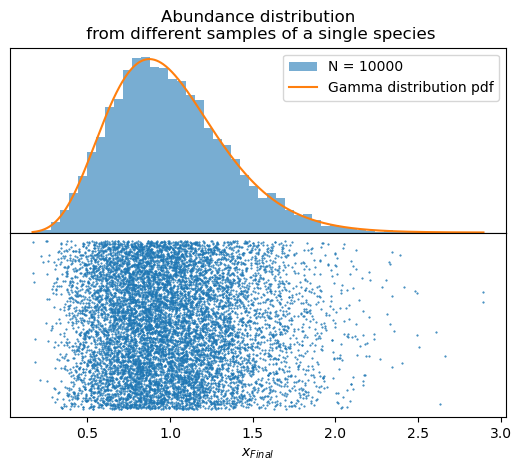

In [12]:
N = 10000
x_0 = np.ones(N)
steps = 10000
dt = 0.01
tau = 4
K = 1.0
sigma = 1
params = (tau, K, sigma)

x = samples(x_0, steps, dt, params)
fig, ax = plt.subplots(nrows=2, gridspec_kw = {'hspace':0})

ax[1].plot(x, np.arange(N), '.', markersize=1)
ax[1].set_xlabel(r"$x_{Final}$")
ax[1].set_yticks([])

mu = x.mean()
std = x.std()
print("mu: ", mu)
print("std: ", std)

_, bins, _ = ax[0].hist(x, bins=50, density=True, alpha=0.6, label=f"N = {N}")

x_range = np.linspace(bins.min(), bins.max(), 1000)

alpha = 2 * tau / sigma**2 
beta = 2 * tau / (K * sigma**2)
gamma = beta**alpha / sc.special.gamma(alpha) * x_range ** (alpha-1) * np.exp(-x_range * beta)
ax[0].plot(x_range, gamma, label="Gamma distribution pdf")
ax[0].set_yticks([])
ax[0].set_xticks([])
ax[0].legend()
ax[0].set_title("Abundance distribution\n from different samples of a single species")

plt.show()

## Segunda ley

Ejecutado paso  0 / 100
Ejecutado paso  10 / 100
Ejecutado paso  20 / 100
Ejecutado paso  30 / 100
Ejecutado paso  40 / 100
Ejecutado paso  50 / 100
Ejecutado paso  60 / 100
Ejecutado paso  70 / 100
Ejecutado paso  80 / 100
Ejecutado paso  90 / 100


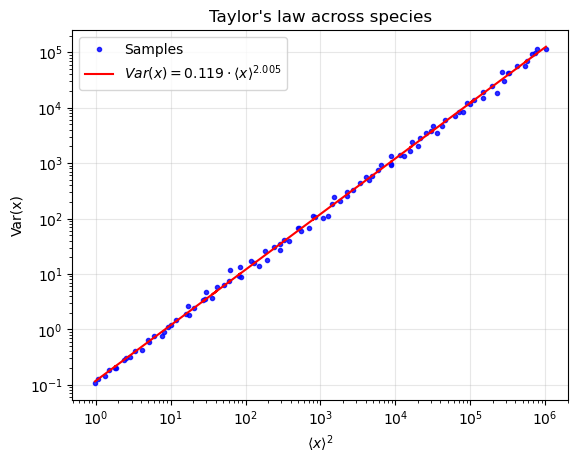

In [15]:
tau_range = 1 / np.linspace(2, 0.1, 100)
K_range = np.logspace(0, 3, 100)
sigma_range = np.sqrt(np.linspace(0, 3, 100))

N = 100
x_0 = np.ones(N)
steps = 5000
dt = 0.01
tau = 4
K = 1
sigma = 1

# Variando tau
variable = K_range
mean = np.zeros(len(variable))
var = np.zeros(len(variable))

for i in range(len(variable)):
    params = (tau, variable[i], sigma)
    x = samples(x_0, steps, dt, params)
    mean[i] = x.mean()
    var[i] = x.var()
    if 10 * i % len(variable) == 0:
        print("Ejecutado paso ", i, "/", len(variable))

# Sample plot
plt.loglog(mean**2, var, 'b.', alpha=0.8, label="Samples")
plt.xlabel(r"$\langle x \rangle^2$")
plt.ylabel("Var(x)")
plt.grid(True, alpha=0.3)

# Curve fit
def f(x, a, b):
    return b * x + a
log_mean = np.log(mean**2)
log_var = np.log(var)
popt, pcov = sc.optimize.curve_fit(f, log_mean, log_var)

y_pred = np.exp(popt[0]) * mean**(2 * popt[1])
plt.loglog(mean**2, y_pred, 'r', label=rf"$Var(x) = {np.exp(popt[0]):.3f} \cdot \langle x\rangle^{{{2 * popt[1]:.3f}}}$")
plt.title("Taylor's law across species")
plt.legend()
plt.show()


## Tercera ley

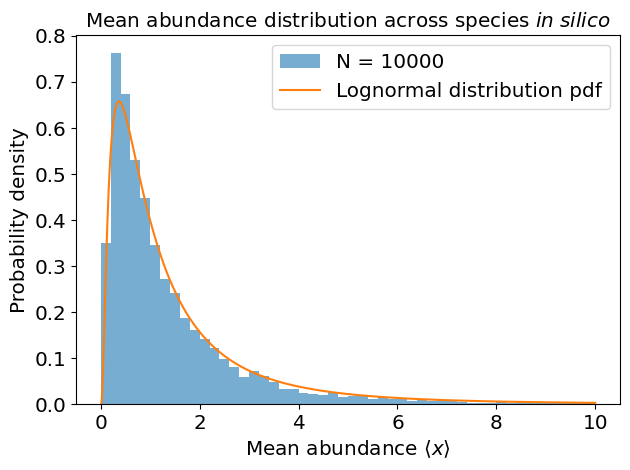

In [52]:
N = 10000
K_range = np.random.lognormal(mean=0, sigma=1, size=N)
x_0 = np.ones(N)
steps = 3000
dt = 0.1
tau = 4
sigma = 1

x_mean = third_law(x_0, steps, dt, (tau, K_range, sigma))

_, bins, _  = plt.hist(x_mean, bins=50, density=True, alpha=0.6, label=f"N = {N}", range=[0, 10])

x_range = np.linspace(0.01, 10, 1000)

loc = 0
scale = 1
lognormal = sc.stats.lognorm.pdf(x_range, 1)
plt.plot(x_range, lognormal, label="Lognormal distribution pdf")
plt.xlabel(r"Mean abundance $\langle x \rangle$", fontsize='x-large')
plt.ylabel("Probability density", fontsize='x-large')
plt.title(r"Mean abundance distribution across species $\it{in\; silico}$", fontsize='x-large')
plt.legend(fontsize='x-large')
plt.tick_params(labelsize='x-large')
plt.tight_layout()
plt.savefig("Tercera ley.pdf")
plt.show()

## Paper de Miguel Ángel

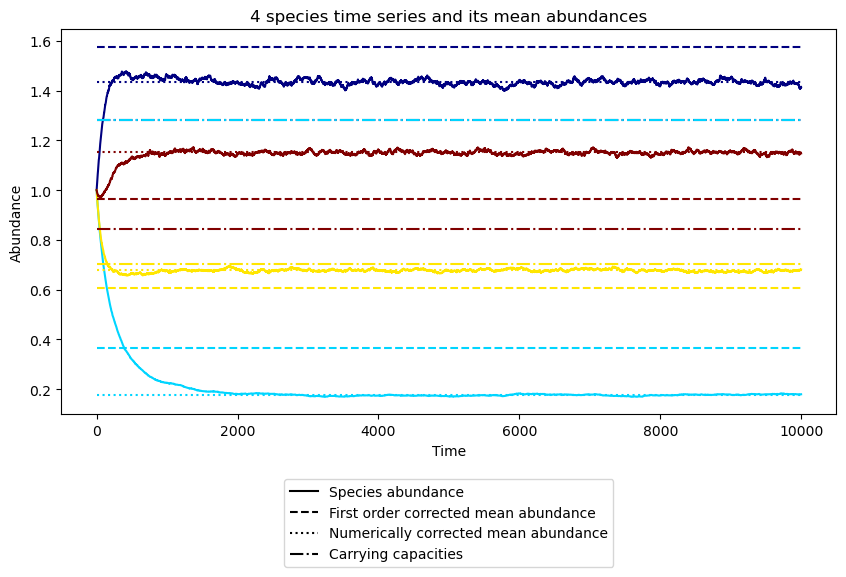

In [3]:
N = 4
dt = 0.01
total_time = 100
steps = int(total_time/dt)
x_0 = np.ones(N)
sigma = 0.01
tau = 1
sigma_ln = 0.5
sigma_n = 0.15
K = np.random.lognormal(sigma=sigma_ln, size=N)

# Creación de la matriz A
N_c = int(N * 0.001/(sigma**2 * K.max()**2))
C = 1
N_c = int(N * N * C)
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)

np.fill_diagonal(A, -1 / K)

fo_mean_abundances = K * (2 + A @ K)
numerical_mean_abundances = -np.linalg.inv(A) @ np.ones(N)

t_series = interacting_time_series(x_0, sigma, tau, dt, A, steps)

# plt.hist(t_series[-1], bins=30, density=True, alpha=0.8)

# Colores
cmap = plt.get_cmap('jet')
valores = np.linspace(0, 1, N)
lista_colores = [cmap(v) for v in valores]

for i in range(N):
    plt.hlines(fo_mean_abundances[i], xmin=0, xmax=steps, color=lista_colores[i], linestyles='--')
    plt.hlines(numerical_mean_abundances[i], xmin=0, xmax=steps, color=lista_colores[i], linestyles=':')
    plt.hlines(K[i], xmin=0, xmax=steps, color=lista_colores[i], linestyles='-.')
    plt.plot(t_series[:, i], color=lista_colores[i])
plt.xlabel("Time")
plt.ylabel("Abundance")
solid = plt.Line2D([], [], linestyle='-', label='Species abundance', color='k')
dashed = plt.Line2D([], [],  linestyle='--', label='First order corrected mean abundance', color='k')
dotted = plt.Line2D([], [],  linestyle=':', label='Numerically corrected mean abundance', color='k')
dash_dot = plt.Line2D([], [],  linestyle='-.', label='Carrying capacities', color='k')

plt.gcf().set_size_inches(10, 5)
plt.legend(handles=[solid, dashed, dotted, dash_dot], loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.title(f"{N} species time series and its mean abundances")
plt.show()




## Jacobian and stablity
### Spectrum of the Jacobian

N_c:  1000000


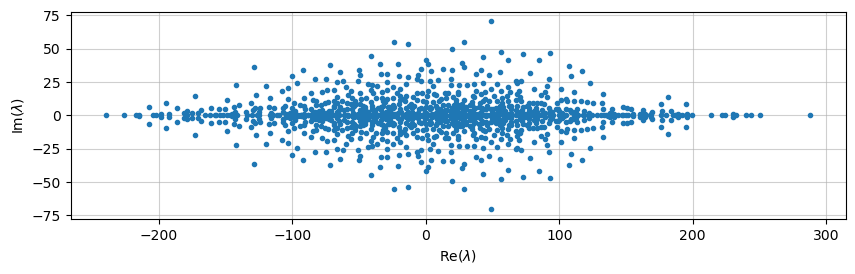

In [138]:
N = 1000

# Generamos la matriz de conexiones según la conectividad C

C = 1
sigma_n = 1
sigma_ln = 1
N_c = int(N * N * C)
print("N_c: ", N_c)
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)
K = np.random.lognormal(sigma=sigma_ln, size=N)
np.fill_diagonal(A, -1/K)

# Calculamos el Jacobiano
diagonal = A @ K + np.random.standard_normal(N)
J = A * K[:, None]
np.fill_diagonal(J, diagonal)

# Calculamos los autovalores
eigenvalues = np.linalg.eigvals(J)
plt.plot(eigenvalues.real, eigenvalues.imag, marker='.', linestyle='', rasterized=True)
plt.grid(True, alpha=0.6)
plt.xlabel(r"Re($\lambda$)")
plt.ylabel(r"Im($\lambda$)") 
plt.gca().set_aspect('equal')
plt.gcf().set_figwidth(10)
plt.show()

### Stability and conectivity

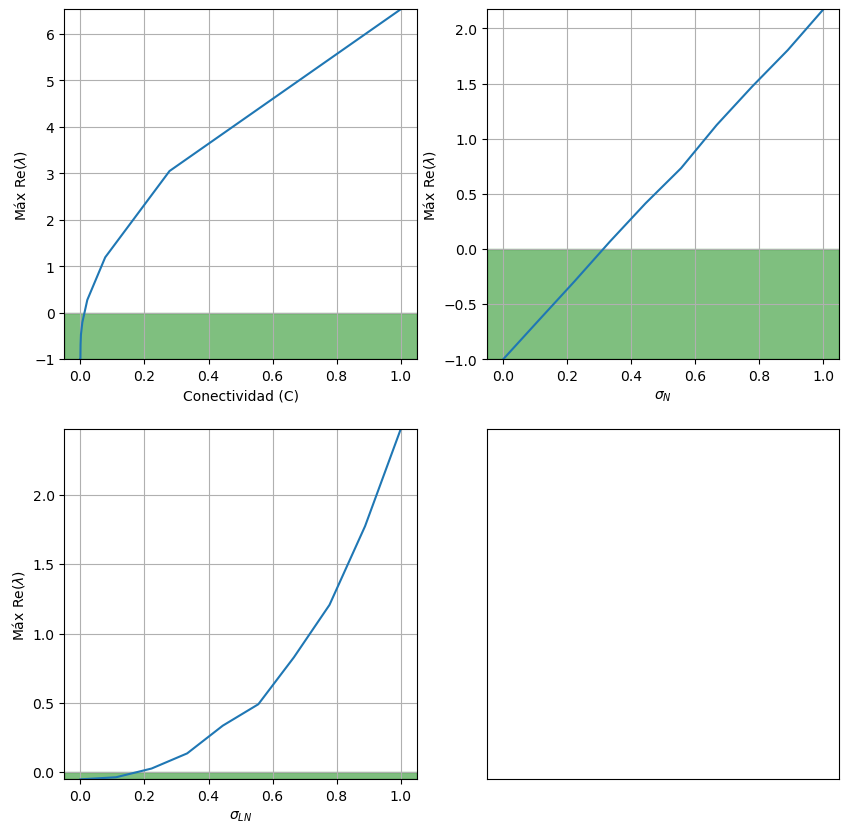

In [111]:
# --- Ejecución ---
N = 100
C_range = np.logspace(-5, 0, 10)
sigma_n_range = np.linspace(0, 1, 10)
sigma_ln_range = np.linspace(0, 1, 10)

single_C = np.array([0.01])
single_sigma_n = np.array([0.3])
single_sigma_ln = np.array([0.03])
n_average = 1000

varying_connections = getMaxRealPart(N, C_range, n_average, single_sigma_n, single_sigma_ln)
varying_sigma_n = getMaxRealPart(N, single_C, n_average, sigma_n_range, single_sigma_ln)
varying_sigma_ln = getMaxRealPart(N, single_C, n_average, single_sigma_n, sigma_ln_range)

# list_max_real_part.shape = (n_connect, n_sn, n_sln)
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))

# Plot variando C
ax[0, 0].plot(C_range, varying_connections[:, 0, 0])
ax[0, 0].set_xlabel("Conectividad (C)")
ax[0, 0].set_ylabel(r"Máx Re($\lambda$)")
ymin = varying_connections[:, 0, 0].min()
ymax = varying_connections[:, 0, 0].max()
ax[0, 0].axhspan(ymin=ymin, ymax=0, color='g', alpha=0.5)
ax[0, 0].set_ylim(ymin, ymax)
ax[0, 0].grid(True)

# Plot variando sigma_n
ax[0, 1].plot(sigma_n_range, varying_sigma_n[0, :, 0])
ax[0, 1].set_xlabel(r"$\sigma_N$")
ax[0, 1].set_ylabel(r"Máx Re($\lambda$)")
ymin = varying_sigma_n[0, :, 0].min()
ymax = varying_sigma_n[0, :, 0].max()
ax[0, 1].axhspan(ymin=ymin, ymax=0, color='g', alpha=0.5)
ax[0, 1].set_ylim(ymin, ymax)
ax[0, 1].grid(True)


# Plot variando sigma_ln
ax[1, 0].plot(sigma_ln_range, varying_sigma_ln[0, 0, :])
ax[1, 0].set_xlabel(r"$\sigma_{LN}$")
ax[1, 0].set_ylabel(r"Máx Re($\lambda$)")
ymin = varying_sigma_ln[0, 0, :].min()
ymax = varying_sigma_ln[0, 0, :].max()
ax[1, 0].axhspan(ymin=ymin, ymax=0, color='g', alpha=0.5)
ax[1, 0].set_ylim(ymin, ymax)
ax[1, 0].grid(True)


ax[1,1].set_xticks([])
ax[1,1].set_yticks([])


plt.show()

## 3D stability representation

In [ ]:
# --- Ejecución ---
N = 100
C_range = np.logspace(-5, 0, 10)
sigma_n_range = np.linspace(0, 1, 10)
sigma_ln_range = np.linspace(0, 1, 10)

n_average = 1000

max_eigenvalue_3D = getMaxRealPart(N, C_range, n_average, sigma_n_range, sigma_ln_range)
voxels = max_eigenvalue_3D < 0

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')

# 4. Dibujar los cubos rellenos
# 'facecolors' define el color de los cubos y 'edgecolor' el de las aristas
ax.voxels(voxels, facecolors='royalblue', edgecolor='black', linewidth=0.5)

# Ajustes estéticos opcionales
ax.set_xlabel('C')
ax.set_ylabel(r'$\sigma_{\mathcal{N}}$')
ax.set_zlabel(r'$\sigma_{\mathcal{LN}}$')
ax.set_title('Visualización de Array 3D (Voxels)')


plt.show()

## Correlation and connectivity

In [ ]:
N = 1000
dt = 0.01
total_time = 10000
steps = int(total_time/dt)
init = int(0.2 * steps)
x_0 = np.ones(N)
sigma = 0.01
tau = 1

# Creación de la matriz A seleccionando la conectividad
C = 1
sigma_n = 0.02
sigma_ln = 0.1
K_range = np.random.lognormal(sigma=sigma_ln, size=N)
N_c = int(N * N * C)
print("N_c: ", N_c)
print("K_max: ", K_range.max())
A = np.zeros((N, N))

rng = np.random.default_rng()
selected_indices = rng.choice(N * N, size=N_c, replace=False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)
np.fill_diagonal(A, -1 / K_range)

# Simulación de las series temporales 
t_series = interacting_time_series(x_0, sigma, tau, dt, A, steps)

corr_matrix = np.corrcoef(t_series[init:], rowvar=False)
enlace = sc.cluster.hierarchy.linkage(corr_matrix, method='ward')
indices_ordenados = sc.cluster.hierarchy.dendrogram(enlace, no_plot=True)['leaves']
matriz_reordenada = corr_matrix[indices_ordenados][:, indices_ordenados]

# Dibujado de las figuras
fig, ax = plt.subplots(ncols=2, figsize=(12, 5), layout='constrained')

# Matriz de correlación agrupada
im1 = ax[1].imshow(matriz_reordenada, vmin=-1, vmax=1, cmap='viridis', aspect='equal', interpolation='None')
fig.colorbar(im1, ax=ax[1])

ax[1].set_title(r"Clustered correlation matrix of $x_i$")

# Matriz de correlación sin agrupar
im0 = ax[0].imshow(corr_matrix, vmin=-1, vmax=1, cmap='viridis', aspect='equal', interpolation='None')
fig.colorbar(im0, ax=ax[0])

ax[0].set_title(r"Original correlation matrix of $x_i$")

plt.show()

# Histograma de las correlaciones
mask = ~np.eye(N, dtype=bool)
plt.hist(corr_matrix[mask], bins=500, density=True, alpha=0.8, range=[-1, 1])
plt.title("Correlation coefficients between species")

std_emp = np.std(corr_matrix[mask])
x_range = np.linspace(-1, 1, 1000)
gaussian = sc.stats.norm.pdf(x_range, scale=std_emp)
plt.plot(x_range, gaussian, label="Normal distribution")
plt.legend()
plt.show()

# Autovalores de las matrices de correlación 
rng = np.random.default_rng()
M = rng.standard_normal((N,N))
random_sym = (M + M.T)/2
corr_eigvals = np.sort(np.linalg.eigvalsh(corr_matrix))[::-1]
random_eigvals = np.sort(np.linalg.eigvalsh(random_sym))[::-1]
plt.loglog(corr_eigvals, marker='.', label="Correlation matrix eigenvalues")
plt.loglog(random_eigvals, marker='.', label="Random matrix eigenvalues")
plt.legend()

N_c:  1000000
K_max:  1.3991523729463449


## Phase transitions

In [43]:
%matplotlib inline
N = 100
C = 0.85

tau = 1

dt = 0.01
steps = int(100/dt)

sigma = 2
A , K = construir_matriz_ISLM(N, C, sigma, 0, 1)

X_0 = np.ones(N)
X_0_pert = X_0 + np.random.normal(0, 1, N)

X = deterministic_interacting_time_series(X_0, tau, dt, A, steps)
X_pert = deterministic_interacting_time_series(X_0_pert, tau, dt, A, steps)

plt.close()
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))

# --- PRIMER GRÁFICO ---

ax[0].plot(X)
ax[0].set_title("Series temporales")

# --- SEGUNDO GRÁFICO ---

ax[1].plot(X_pert)
ax[1].set_title("Series temporales")

plt.show()

/home/olmoviviens/miniforge3/envs/fisica/lib/python3.12/site-packages/matplotlib/ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale
/home/olmoviviens/miniforge3/envs/fisica/lib/python3.12/site-packages/matplotlib/ticker.py:2220: RuntimeWarning: overflow encountered in scalar subtract
  high = edge.ge(_vmax - best_vmin)
/home/olmoviviens/miniforge3/envs/fisica/lib/python3.12/site-packages/matplotlib/ticker.py:2036: RuntimeWarning: invalid value encountered in scalar divmod
  d, m = divmod(x, self.step)


ValueError: arange: cannot compute length

<Figure size 1000x500 with 2 Axes>

## Comprobación de las leyes con interacciones 

N_c:  40
K_max:  1.0748614262465006
ALPHA:  199.99999999999997


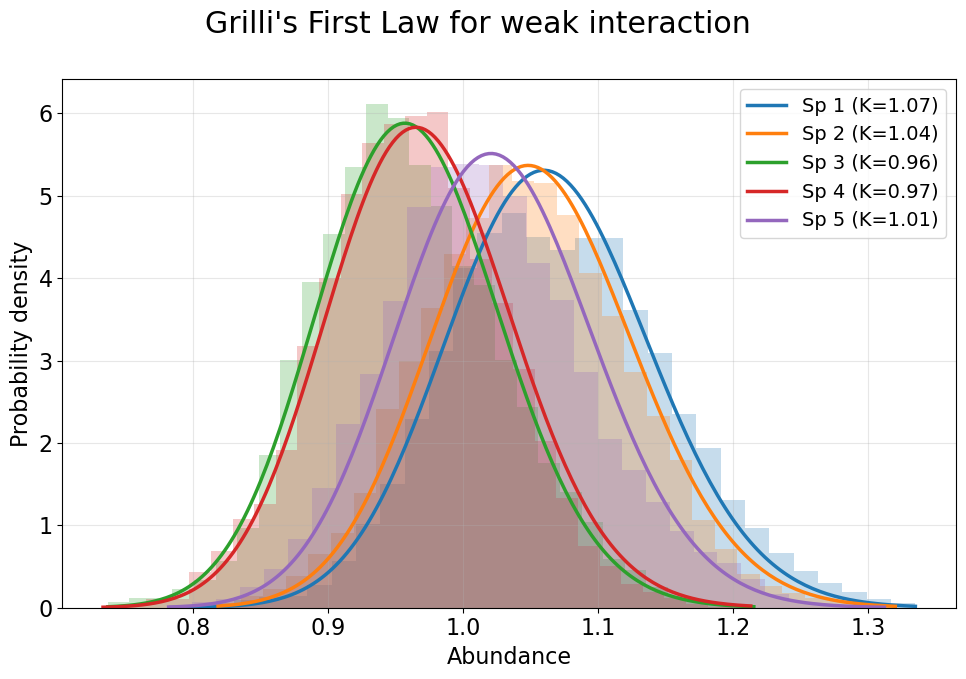

In [6]:
from scipy.stats import gamma

N = 20
dt = 0.01
total_time = 500
steps = int(total_time/dt)
init = int(0.2 * steps)
x_0 = np.ones(N)
sigma = 0.01
tau = 1

# Creación de la matriz A seleccionando la conectividad
C = 0.1
sigma_n = 0.01
sigma_ln = 0.05
K_range = np.random.lognormal(sigma=sigma_ln, size=N)
N_c = int(N * N * C)
print("N_c: ", N_c)
print("K_max: ", K_range.max())
A = np.zeros((N, N))

rng = np.random.default_rng()
selected_indices = rng.choice(N * N, size=N_c, replace=False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)
np.fill_diagonal(A, -1 / K_range)

# Ruido
w = 0.1
par1_Gamma = 2 / (tau * w**2)      #Parámetro alpha de la distribución Gamma
print("ALPHA: ", par1_Gamma)

par2_Gamma = np.zeros(N)
# Simulación de las series temporales 
t_series = interacting_time_series(x_0, w, tau, dt, A, steps)

# Descarte del transitorio (solo estado estacionario)
transitorio = int(steps * 0.3) 
t_ser_est = t_series[transitorio:]

# CONFIGURACIÓN DE GRÁFICA: Un único recuadro para las primeras 5 especies
fig, ax = plt.subplots(figsize=(10, 7))

colores = ['#1f77b4', '#ff7f0e', '#2ca02c', "#d62727", '#9467bd']
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14
})

# Cálculo inverso de la matriz completo necesario para el parámetro teórico
inv_A = np.linalg.inv(A)

# MODIFICACIÓN CRUCIAL: Cambiado el rango a range(5) para tomar solo las primeras 5 especies
for i in range(5):
    color_actual = colores[i]

    # Distribución Gamma numérica
    datos_especie = t_ser_est[:, i]
    
    # Graficamos el histograma en el recuadro único
    ax.hist(datos_especie, bins=30, density=True, alpha=0.25, color=color_actual)

    # Distribución Gamma teórica
    par2_Gamma[i] = 2 / (tau * w**2 * (-inv_A @ np.ones(N))[i])     # Parámetro lambda teórico

    x_axis = np.linspace(datos_especie.min(), datos_especie.max(), 200)
    pdf_teorica = gamma.pdf(x_axis, a=par1_Gamma, scale=1/par2_Gamma[i])

    # Graficamos la curva teórica continua
    ax.plot(x_axis, pdf_teorica, color=color_actual, linewidth=2.5, 
            label=f'Sp {i+1} (K={K_range[i]:.2f})')

# Ajustes estéticos del recuadro único

ax.set_xlabel('Abundance')
ax.set_ylabel('Probability density')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right') 

# Título global y ajuste de espacios
plt.suptitle("Grilli's First Law for weak interaction ")
plt.tight_layout()
plt.savefig('FIRST_LAW_top5_interaction.png')
plt.show()

In [ ]:
# Cálculo de los logaritmos de la media y la varianza en estado estacionario

N = 50
dt = 0.01
total_time = 500
steps = int(total_time/dt)
init = int(0.2 * steps)
x_0 = np.ones(N)
sigma = 0.01
tau = 1

# Creación de la matriz A seleccionando la conectividad
C = 0.001
sigma_n = 0.01
sigma_ln = 0.05
K_range = np.random.lognormal(sigma=sigma_ln, size=N)
N_c = int(N * N * C)
print("N_c: ", N_c)
print("K_max: ", K_range.max())
A = np.zeros((N, N))

rng = np.random.default_rng()
selected_indices = rng.choice(N * N, size=N_c, replace=False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)
np.fill_diagonal(A, -1 / K_range)

# Ruido
w = 0.1
par1_Gamma = 2 / (tau * w**2)      #Parámetro alpha de la distribución Gamma



# Simulación de las series temporales 
t_series = interacting_time_series(x_0, w, tau, dt, A, steps)

# Descarte del transitorio (solo estado estacionario)
transitorio = int(steps * 0.3) 
t_ser_est = t_series[transitorio:]

taylor_mean = np.zeros(N)
taylor_var = np.zeros(N)

for i in range(N):
    taylor_mean[i] = np.log10(np.mean(t_ser_est[:,i]))
    taylor_var[i] = np.log10(np.var(t_ser_est[:,i]))

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})


# Gráfico de la nube de puntos y la recta y=2x superpuesta
x_taylor = np.linspace(taylor_mean.min(), taylor_mean.max(), 100)
plt.scatter(taylor_mean, taylor_var, label = "Numerical solution")
#plt.plot(x_taylor, 2*x_taylor-2.3, color = "red", label = "y=2x")

# Ajuste lineal de la nube de puntos
m, b = np.polyfit(taylor_mean, taylor_var, 1)
plt.plot(x_taylor, m*x_taylor + b, label = f"Linear fit: {m:.2f}x {b:.2f}", color = "orange")
#plt.plot(x_taylor, 2*x_taylor, label = "y=2x", color = "orange")

print("Pendiente, m = ",m, "\nOrdenada en origen, b = ",b)

plt.xlabel("$log_{10}(<x_i>)$")
plt.ylabel("$log_{10}(Var(x_i))$")
plt.title("Taylor's Law for weak interaction")

#plt.grid(True)
plt.legend()
plt.grid(True, alpha = 0.6)
plt.savefig('TAYLOR_interaccion.png')
plt.show()

In [ ]:
# Parámetros de la simulación
N = 1000 
steps = 5000
dt = 0.01
tau = 4
sigma = 0.01
w=sigma**2
K_range = np.random.lognormal(mean=0, sigma=0.5, size=N)
x_0 = np.ones(N)

# Creación de la matriz A
N_c = int(N * 0.001/(sigma**2 * K_range.max()**2))
C = 0.0001
N_c = int(N * N * C)
print("N_c: ", N_c)
print("K_max: ", K_range.max())
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.standard_normal(size=N_c)
np.fill_diagonal(A, -1 / K_range)

x = third_law_interaccion(x_0, steps, dt, (tau, K_range, sigma), A)
#print(x)
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

_, bins, _  = plt.hist(x, bins=50, density=True, alpha=0.6, label=f"N = {N}", range=[0, 10])

x_third_law = np.linspace(0.01, 10, 1000)

loc = 0

media_exp = np.mean(x)
var_exp = np.var(x) 
# Conversión de parámetros para la Lognormal de SciPy
sigma_teorico = np.sqrt(np.log(1 + var_exp / (media_exp**2)))
scale_teorico = (media_exp**2) / np.sqrt(media_exp**2 + var_exp)
plt.xlabel('Mean Abundance', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Third Law for weak interaction')

lognormal_ajustada = sc.stats.lognorm.pdf(x_third_law, s=sigma_teorico, scale=scale_teorico)
plt.plot(x_third_law, lognormal_ajustada, color="orange", label="Teoría Lognormal Ajustada")
plt.savefig("TERCERA_LEY_INTERACCION.png")

## Ruido correlacionado

In [ ]:
# Parámetros de la simulación
N = 5
dt = 0.01
total_time = 100
steps = int(total_time/dt)
x_0 = np.ones(N)
sigma = 0.1
tau = 1
sigma_ln = 0.1
sigma_n = 0.1
K = np.random.lognormal(sigma=sigma_ln, size=N)
mu_w=0.0
sigma_w=1.0

tau_noise = 1.2
# rho es la fraccion de ruido global respecto del local, ruido = rho * global + (1-rho) * local 
# así, la "sequía" no afecta a todas exactamente por igual
rho = 0.3

# Creación de la matriz A
N_c = int(N * 0.001/(sigma**2 * K.max()**2))
C = 0.5
N_c = int(N * N * np.abs(C))
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)


np.fill_diagonal(A, -1 / K)

# Matriz de ruido correlacionado W
W = np.random.normal(mu_w, sigma_w, size=(N,N))
np.fill_diagonal(W, 0.0)
W = W/np.sqrt(N-1)


mean_abundances = K * (2 + A @ K)
mean_abundance_not_approx = (-np.linalg.inv(A) @ np.ones(N))

t_series_noise = interacting_time_series_noise(x_0, sigma, tau, dt, A, steps, rho, tau_noise, W)

# plt.hist(t_series[-1], bins=30, density=True, alpha=0.8)

# Colores
cmap = plt.get_cmap('jet')
valores = np.linspace(0, 1, N)
lista_colores = [cmap(v) for v in valores]
plt.figure(figsize=(9, 6))
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14
})

for i in range(N):
    # plt.hlines(K_range[i], xmin=0, xmax=steps, alpha=0.6, color=lista_colores[i], linestyles='--')
    plt.hlines(mean_abundances[i], xmin=0, xmax=steps, color=lista_colores[i], linestyles='--')
    plt.hlines(mean_abundance_not_approx[i], xmin=0, xmax=steps, color=lista_colores[i])
    plt.plot(t_series_noise[:, i], color=lista_colores[i])
plt.xlabel("Time")
plt.ylabel("Abundance")
solid = plt.Line2D([], [], linestyle='-', label='Species abundance', color='k')
dashed = plt.Line2D([], [],  linestyle='--', label='Corrected mean abundance', color='k')

#plt.gcf().set_size_inches(10, 5)
plt.legend(handles=[solid, dashed], loc='lower center', bbox_to_anchor=(0.5, 1.02))
plt.savefig("trayectorias_correlated_noise.png")
plt.show()

In [ ]:
from scipy.stats import gamma


transitorio_noise = int(steps * 0.1) 
t_ser_est_noise = t_series_noise[transitorio_noise:]

# --- NUEVA CONFIGURACIÓN DE UN ÚNICO GRÁFICO ---
plt.figure(figsize=(9, 6))

colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62727', '#9467bd']

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# Graficamos las 5 especies juntas en el mismo eje
for i in range(N):
    datos_especie = t_ser_est_noise[:, i]
    
    # 1. Histograma numérico (bajamos alpha a 0.25 para que al solaparse no se emborrone)
    plt.hist(datos_especie, bins=40, density=True, alpha=0.6, color=lista_colores[i])
    
    

# Ajustes estéticos finales del gráfico único
plt.title("Grilli's First Law (Abundance Distribution for $N=5$)", pad=15, fontsize=16)
plt.xlabel('Abundance ($x$)', fontsize=14)
plt.ylabel('Probability Density ($P(x)$)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.savefig('FIRST_LAW_interaction_noise.png', bbox_inches='tight')
plt.show()

In [ ]:
# Parámetros de la simulación
N = 50
dt = 0.01
total_time = 100
steps = int(total_time/dt)
x_0 = np.ones(N)
sigma = 0.1
tau = 1
sigma_ln = 0.1
sigma_n = 0.1
K = np.random.lognormal(sigma=sigma_ln, size=N)

tau_noise = 1
# rho es la fraccion de ruido global respecto del local, ruido = rho * global + (1-rho) * local 
# así, la "sequía" no afecta a todas exactamente por igual
rho = 0.3

# Creación de la matriz A
N_c = int(N * 0.001/(sigma**2 * K.max()**2))
C = 0.1
N_c = int(N * N * np.abs(C))
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)

np.fill_diagonal(A, -1 / K)
# # Matriz de ruido correlacionado W
W = np.random.normal(mu_w, sigma_w, size=(N,N))
np.fill_diagonal(W, 0.0)
W = W/np.sqrt(N-1)

mean_abundances = K * (2 + A @ K)
mean_abundance_not_approx = (-np.linalg.inv(A) @ np.ones(N))

t_series_noise = interacting_time_series_noise(x_0, sigma, tau, dt, A, steps, rho, tau_noise, W)


taylor_mean_noise = np.zeros(N)
taylor_var_noise = np.zeros(N)


for i in range(N):
    taylor_mean_noise[i] = np.log10(np.mean(t_series_noise[:,i]))
    taylor_var_noise[i] = np.log10(np.var(t_series_noise[:,i]))


plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})


# Gráfico de la nube de puntos y la recta y=2x superpuesta
x_taylor_noise = np.linspace(taylor_mean_noise.min(), taylor_mean_noise.max(), 100)
plt.scatter(taylor_mean_noise, taylor_var_noise, label = "Numerical solution")
#plt.plot(x_taylor, 2*x_taylor-2.3, color = "red", label = "y=2x")

# Ajuste lineal de la nube de puntos
#m, b = np.polyfit(taylor_mean_noise, taylor_var_noise, 1)
plt.plot(x_taylor_noise, 2*x_taylor_noise-2.8, label = f"y=2x", color = "orange")
#plt.plot(x_taylor, 2*x_taylor, label = "y=2x", color = "orange")

#print("Pendiente, m = ",m, "\nOrdenada en origen, b = ",b)

plt.xlabel("$log_{10}(<x_i>)$")
plt.ylabel("$log_{10}(Var(x_i))$")
plt.title("Taylor's Law with correlated noise")

#plt.grid(True)
plt.legend()
plt.grid(True, alpha = 0.6)
plt.savefig('TAYLOR_interaccion_noise.png')
plt.show()


In [ ]:
# Parámetros de la simulación
N = 100
dt = 0.01
total_time = 100
steps = int(total_time/dt)
x_0 = np.ones(N)
sigma = 0.1
tau = 1
sigma_ln = 0.1
sigma_n = 0.1
K = np.random.lognormal(sigma=sigma_ln, size=N)

tau_noise = 1
# rho es la fraccion de ruido global respecto del local, ruido = rho * global + (1-rho) * local 
# así, la "sequía" no afecta a todas exactamente por igual
rho = 0.3

# Creación de la matriz A
N_c = int(N * 0.001/(sigma**2 * K.max()**2))
C = 0.1
N_c = int(N * N * np.abs(C))
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)

np.fill_diagonal(A, -1 / K)
# # Matriz de ruido correlacionado W
W = np.random.normal(mu_w, sigma_w, size=(N,N))
np.fill_diagonal(W, 0.0)
W = W/np.sqrt(N-1)

mean_abundances = K * (2 + A @ K)
mean_abundance_not_approx = (-np.linalg.inv(A) @ np.ones(N))

t_series_noise = interacting_time_series_noise(x_0, sigma, tau, dt, A, steps, rho, tau_noise, W)
abundancias_medias = np.mean(t_series_noise, axis=0)
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

_, bins, _  = plt.hist(abundancias_medias, bins=50, density=True, alpha=0.6, label=f"N = {N}", range=[0, 5])

x_third_law = np.linspace(0.01, 5, 500)

loc = 0

media_exp = np.mean(abundancias_medias)
var_exp = np.var(abundancias_medias) 
# Conversión de parámetros para la Lognormal de SciPy
sigma_teorico = np.sqrt(np.log(1 + var_exp / (media_exp**2)))
scale_teorico = (media_exp**2) / np.sqrt(media_exp**2 + var_exp)
plt.xlabel('Mean Abundance', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Third Law with correlated noise')

lognormal_ajustada = sc.stats.lognorm.pdf(x_third_law, s=sigma_teorico, scale=scale_teorico)
plt.plot(x_third_law, lognormal_ajustada, color="orange", label="Teoría Lognormal Ajustada")
plt.savefig("TERCERA_LEY_INTERACCION_noise.png")

# Datos de especies reales


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gamma

df = pd.read_csv('cleaned_useful_species.csv', sep=',', index_col=0)           #Leer fichero de abundancias MGYS00005791 MGnify EBI
m_abund=df.values               #Matriz de abundancias de las especies
n_esp=len(m_abund)
n_muestra=len(df.columns)
#print(m_abund)


vec_mean = np.zeros(n_esp)
vec_var= np.zeros(n_esp)
seg_mom=np.zeros(n_esp)

#vectores que contienen los parámetros de la distribución gamma
alpha_gamma = np.zeros(n_esp)
lambda_gamma = np.zeros(n_esp)
ratio=np.zeros(n_esp)


for i in range(n_esp):
    suma_momentos = 0
    media = 0

    # Cálculo del PRIMER Y SEGUNDO MOMENTO
    for s in range(n_muestra):
        Ns=np.sum(m_abund[:,s])
        
        if Ns > 1:
            media += (m_abund[i,s]/Ns)
            numerador = m_abund[i, s] * (m_abund[i, s] - 1)
            denominador = Ns * (Ns - 1)
            suma_momentos += (numerador / denominador)
    seg_mom[i] = suma_momentos*(1/n_muestra)
    
    vec_mean[i] = (1/n_muestra)*media
    vec_var[i] = seg_mom[i] - (vec_mean[i]**2)

    
    #calculos de los parámetros de la distribución 
    alpha_gamma[i] = vec_mean[i]**2/vec_var[i]
    lambda_gamma[i] = vec_mean[i]/vec_var[i]
    ratio[i]=vec_var[i]/vec_mean[i]**2
    # Crear el histograma de los datos reales
    plt.hist(m_abund[i,:], bins=20, density=True, alpha=0.6)
    # Crear la curva teórica Gamma
x = np.linspace(0, np.max(m_abund[i,:]), 100)
y = gamma.pdf(x, a=alpha_gamma.max(), scale=lambda_gamma.min())

plt.plot(x, y, 'r-', lw=2)
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

plt.xlim(-0.5, 15)
plt.title('First Law (AFD) with real data')
plt.xlabel('Abundance')
plt.ylabel('Probability Density')
plt.legend()
#plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig("esp_reales_PRIMERA_LEY.png")
plt.show()

In [ ]:
#plot de la varianza vs la media
# Preparar los datos en logaritmos
x_log = abs(np.log10(vec_mean))
y_log = abs(np.log10(abs(vec_var)))

plt.scatter(x_log,y_log, label="Experimental data")

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})
x_func = np.linspace(1,3)
#plt.plot(x_func, m*x_func + ord_origin, color="red", label="Ajuste lineal")
plt.plot(x_func, 2*x_func, color="orange", label="y=2x")
plt.xlabel("$log_{10}(<x_i>)$")
plt.ylabel("$log_{10}(Var(x_i))$")
plt.title("Taylor's Law with real data")
plt.legend()
plt.grid(True, alpha=0.4)
plt.savefig("esp_reales_SEGUNDA_LEY.png")

plt.show()

In [ ]:
from scipy.stats import lognorm
import scipy.stats as st

abundancias_globales = m_abund.flatten()
abundancias_positivas = abundancias_globales[abundancias_globales > 0]
# Calculamos la media y la varianza experimentales directas de tus datos reales
media_exp = np.mean(abundancias_positivas)
var_exp = np.var(abundancias_positivas)
media_var_log = np.mean(vec_var[vec_var > 0])
   

print(f"Número de especies analizadas: {m_abund.shape[0]}")
print(f"Número de muestras por especie: {m_abund.shape[1]}")
print(f"Media global: {media_exp:.4f}")
print(f"Varianza global: {var_exp:.4f}")
print(f"Varianza global corregida: {media_var_log:.4f}")

plt.figure(figsize=(8, 5))
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# Histograma de los datos reales
count, bins, _ = plt.hist(abundancias_positivas, bins=50, density=True, alpha=0.6, label="Experimental data", range=[0.01, abundancias_globales.max()])

x_tercera_ley = np.linspace(0.01, abundancias_positivas.max(), 1000)

shape_mle, loc_mle, scale_mle = st.lognorm.fit(abundancias_positivas, floc=0)

sigma_teorico_log = np.sqrt(np.log(1 + media_var_log / (media_exp**2)))
scale_teorico_log = (media_exp**2) / np.sqrt(media_exp**2 + media_var_log)

lognormal_ajustada = st.lognorm.pdf(x_tercera_ley, s=shape_mle, loc=loc_mle, scale=scale_mle)
plt.plot(x_tercera_ley, lognormal_ajustada, color="orange", linewidth=2.5, label="Lognormal Theory")


# Estética del gráfico
plt.title('Third Law with real data')
plt.xlabel('Mean Abundance', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(0, m_abund.max())
#plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.savefig("esp_reales_TERCERA_LEY.png")
plt.show()